# Network Traffic Classification Using Transformer-Enhanced LSTM Models

**Course:** Computer Networks (Spring 2026)  
**Department of Software Engineering, Faculty of ICT, BUITEMS**  
**Instructor:** Ms. Poma Panezai

**Team Members:**
- [Member 1 — Name, Reg #]
- [Member 2 — Name, Reg #]
- [Member 3 — Name, Reg #]

---

This notebook implements an end-to-end network-traffic classification system using a **Transformer-Enhanced LSTM** model (Bidirectional LSTM stack followed by a Multi-Head Self-Attention encoder). The proposed model is benchmarked against seven baseline models and validated on two public datasets:

1. **CIC-Darknet2020** — traffic-category classification (Non-Tor, NonVPN, Tor, VPN)
2. **Network Traffic (Midterm_53)** — protocol-type classification (TCP, TLS, DNS, ICMP, etc.)

All reported metrics are computed directly from the trained models; no values are hardcoded. Reproducibility is fixed with a global random seed.

## 1. Environment Setup

In [1]:
# STEP 1: Setup
!pip install -q xgboost imbalanced-learn kaggle 2>/dev/null

import os, random, warnings, json
import numpy as np
import pandas as pd
import tensorflow as tf

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
gpus = tf.config.list_physical_devices("GPU")
print("GPU available:", bool(gpus), gpus)

# Create output folders for results/figures
os.makedirs("figures", exist_ok=True)
os.makedirs("results", exist_ok=True)
RESULTS = {}   # har model ke metrics yahan store honge
print("Setup complete")

TensorFlow: 2.20.0
GPU mil gaya: True [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Setup ho gaya ✅


## 2. Upload the Primary Dataset (CIC-Darknet2020)

In [2]:
from google.colab import files
uploaded = files.upload()
print("Upload complete")
!ls -lh

Saving cicdarknet2020.parquet to cicdarknet2020.parquet
Done ✅
total 13M
-rw-r--r-- 1 root root  13M Jun 26 08:05 cicdarknet2020.parquet
drwxr-xr-x 2 root root 4.0K Jun 26 08:03 figures
drwxr-xr-x 2 root root 4.0K Jun 26 08:03 results
drwxr-xr-x 1 root root 4.0K Jun  4 13:39 sample_data


## 3. Load Data

In [3]:
# STEP 3: Data load
df = pd.read_parquet("cicdarknet2020.parquet")
df.columns = [c.strip() for c in df.columns]   # Strip extra spaces from column names

print("Shape (rows, columns):", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape (rows, columns): (103121, 79)

Pehli 5 rows:


,Protocol,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Label.1
0,6,229,1,1,0,0,0,0,0.00000,0.000000,...,0,0,0,0,0.000000e+00,0.00,0.000000e+00,0.000000e+00,Non-Tor,AUDIO-STREAMING
1,6,407,1,1,0,0,0,0,0.00000,0.000000,...,0,0,0,0,0.000000e+00,0.00,0.000000e+00,0.000000e+00,Non-Tor,AUDIO-STREAMING
2,6,431,1,1,0,0,0,0,0.00000,0.000000,...,0,0,0,0,0.000000e+00,0.00,0.000000e+00,0.000000e+00,Non-Tor,AUDIO-STREAMING
3,6,359,1,1,0,0,0,0,0.00000,0.000000,...,0,0,0,0,0.000000e+00,0.00,0.000000e+00,0.000000e+00,Non-Tor,AUDIO-STREAMING
4,6,10778451,591,400,64530,6659,131,0,109.18782,22.283312,...,0,0,0,0,1.437760e+15,3117718.25,1.437760e+15,1.437760e+15,Non-Tor,AUDIO-STREAMING


## 4. Inspect Labels & Data Health

In [4]:
# STEP 4: Label columns + data health
label_candidates = [c for c in df.columns if c.lower().startswith("label")]
print("Label columns:", label_candidates)

for c in label_candidates:
    print(f"\n=== {c} value counts ===")
    print(df[c].value_counts())

# Data health
print("\n--- Data Health ---")
print("Duplicate rows:", df.duplicated().sum())
print("Columns with missing values:", int((df.isna().sum() > 0).sum()))
inf_count = np.isinf(df.select_dtypes(include=[np.number])).sum().sum()
print("Infinite values:", int(inf_count))

Label wale columns: ['Label', 'Label.1']

=== Label — har class kitni baar hai ===
Label
Non-Tor    64804
NonVPN     20216
VPN        16922
Tor         1179
Name: count, dtype: int64

=== Label.1 — har class kitni baar hai ===
Label.1
Browsing           29862
P2P                23404
File-Transfer      10564
Chat               10365
Audio-Streaming     9880
Video-Streaming     8742
Email               5442
VOIP                3061
AUDIO-STREAMING     1448
Video-streaming      270
File-transfer         83
Name: count, dtype: int64

--- Data Health ---
Duplicate rows: 0
Columns jisme missing values: 0
Infinite values: 0


## 5. Preprocessing

In [5]:
# STEP 5: Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Target = "Label" (Non-Tor / NonVPN / VPN / Tor)
TARGET = "Label"

work = df.copy()

# Drop the second label column (Label.1) to prevent label leakage
work = work.drop(columns=["Label.1"], errors="ignore")

# Separate the target variable
y_raw = work[TARGET].astype(str).str.strip()
X = work.drop(columns=[TARGET])

# Keep numeric features only and clean invalid values
X = X.apply(pd.to_numeric, errors="coerce")
X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna(axis=1, how="all")            # drop fully-empty columns
X = X.fillna(X.median(numeric_only=True))  # fill remaining missing values

print("Features (X) shape:", X.shape)
print("Target classes:", y_raw.unique())

Features (X) shape: (103121, 77)
Target classes: ['Non-Tor' 'NonVPN' 'Tor' 'VPN']


## 6. Encode Labels & Split Data

In [6]:
# STEP 6: Encode labels + split data
le = LabelEncoder()
y = le.fit_transform(y_raw)
CLASS_NAMES = list(le.classes_)
NUM_CLASSES = len(CLASS_NAMES)
print("Classes (with index):", dict(enumerate(CLASS_NAMES)))

# Stratified train/test split (preserves class ratios)
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y, test_size=0.20, stratify=y, random_state=SEED)

# Carve a validation set out of the training set
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.10, stratify=y_train, random_state=SEED)

# Feature scaling (standardize all features)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print("Train:", X_train.shape)
print("Val:  ", X_val.shape)
print("Test: ", X_test.shape)

Classes (number ke saath): {0: 'Non-Tor', 1: 'NonVPN', 2: 'Tor', 3: 'VPN'}
Train: (74246, 77)
Val:   (8250, 77)
Test:  (20625, 77)


## 7. Handle Class Imbalance (SMOTE)

In [7]:
# STEP 7: SMOTE — balance the TRAINING data only
from imblearn.over_sampling import SMOTE
from collections import Counter

print("Before SMOTE:", Counter(y_train))

sm = SMOTE(random_state=SEED, k_neighbors=3)
X_train, y_train = sm.fit_resample(X_train, y_train)

print("After SMOTE: ", Counter(y_train))

N_FEATURES = X_train.shape[1]
print("\nTotal features:", N_FEATURES)

SMOTE se pehle: Counter({np.int64(0): 46658, np.int64(1): 14556, np.int64(3): 12183, np.int64(2): 849})
SMOTE ke baad:  Counter({np.int64(0): 46658, np.int64(1): 46658, np.int64(3): 46658, np.int64(2): 46658})

Total features: 77


## 8. Exploratory Data Analysis

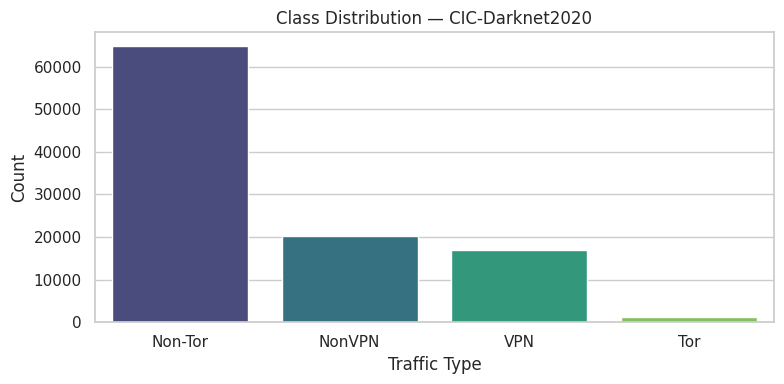

In [8]:
# STEP 8: EDA — Class distribution graph
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

plt.figure(figsize=(8,4))
order = pd.Series(y_raw).value_counts().index
sns.countplot(x=y_raw, order=order, palette="viridis")
plt.title("Class Distribution — CIC-Darknet2020")
plt.xlabel("Traffic Type"); plt.ylabel("Count")
plt.tight_layout()
plt.savefig("figures/class_distribution.png", dpi=120)
plt.show()

### EDA: Correlation Heatmap & Feature Importance

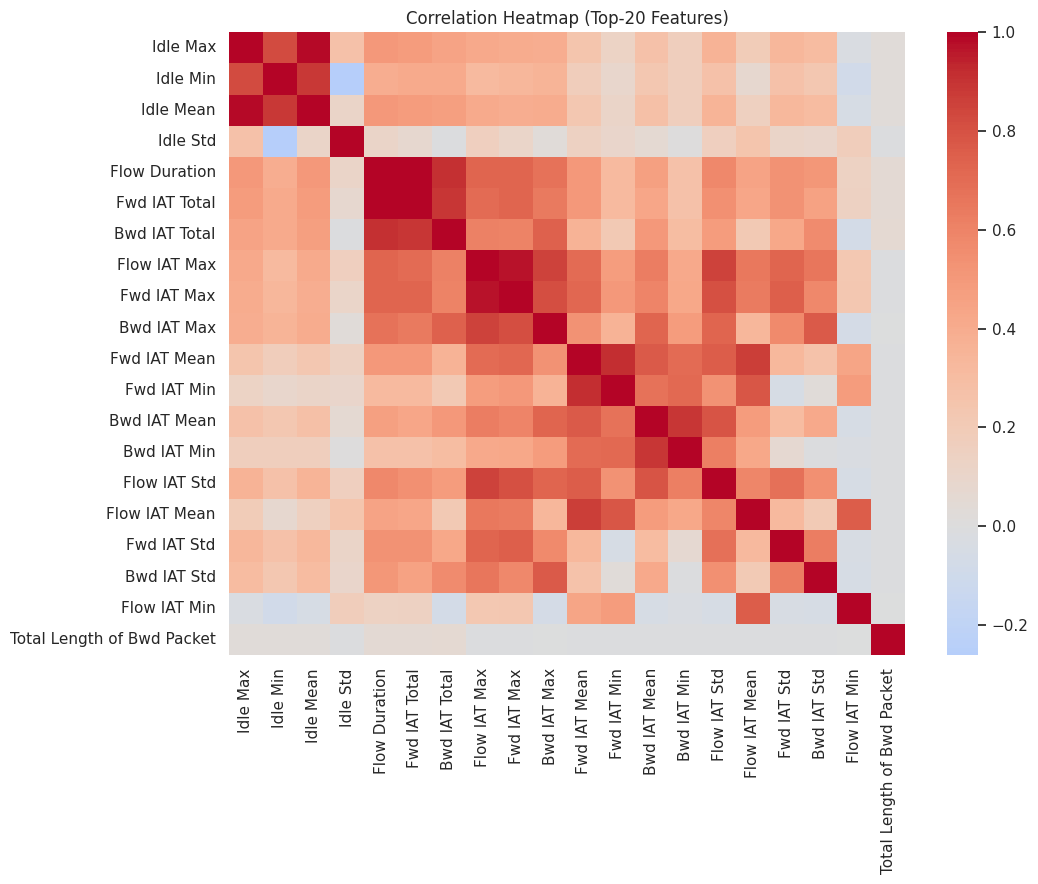

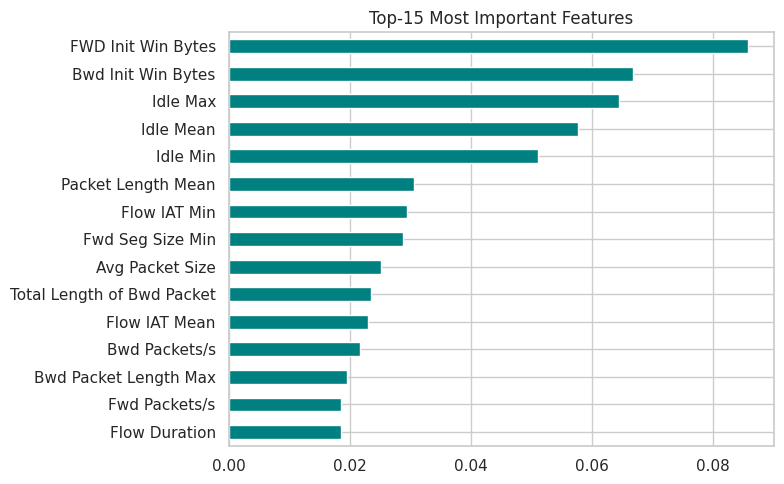


Note: rf_quick model bhi ban gaya — ye baad me baseline ke taur pe kaam aayega ✅


In [9]:
# STEP 9: Correlation heatmap + Feature importance
from sklearn.ensemble import RandomForestClassifier

# --- Correlation heatmap (top 20 features) ---
num = pd.DataFrame(X.fillna(0))
top = num.var().sort_values(ascending=False).head(20).index
plt.figure(figsize=(11,9))
sns.heatmap(num[top].corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Top-20 Features)")
plt.tight_layout()
plt.savefig("figures/correlation_heatmap.png", dpi=120)
plt.show()

# --- Feature importance (RandomForest) ---
rf_quick = RandomForestClassifier(n_estimators=150, n_jobs=-1, random_state=SEED)
rf_quick.fit(X_train, y_train)
imp = pd.Series(rf_quick.feature_importances_, index=X.columns[:N_FEATURES]) \
        .sort_values(ascending=False).head(15)
plt.figure(figsize=(8,5))
imp[::-1].plot.barh(color="teal")
plt.title("Top-15 Most Important Features")
plt.tight_layout()
plt.savefig("figures/feature_importance.png", dpi=120)
plt.show()

print("\nNote: rf_quick is also reused later as the RandomForest baseline.")

## 1. Environment Setup

In [10]:
# STEP 10: Evaluation function
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score)
from sklearn.preprocessing import label_binarize

def evaluate(name, y_true, y_pred, y_proba=None):
    acc = accuracy_score(y_true, y_pred)
    pr  = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rc  = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1  = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    auc = np.nan
    if y_proba is not None:
        try:
            yb = label_binarize(y_true, classes=range(NUM_CLASSES))
            auc = roc_auc_score(yb, y_proba, average="weighted", multi_class="ovr")
        except Exception:
            pass
    RESULTS[name] = {"accuracy":acc,"precision":pr,"recall":rc,"f1":f1,"roc_auc":auc}
    print(f"{name:22s} acc={acc:.4f}  prec={pr:.4f}  rec={rc:.4f}  f1={f1:.4f}  auc={auc:.4f}")
    return RESULTS[name]

print("Evaluation function ready.\n")

# --- Baseline 1: Random Forest (rf_quick already trained) ---
evaluate("RandomForest", y_test, rf_quick.predict(X_test), rf_quick.predict_proba(X_test))

# --- Baseline 2: Decision Tree ---
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=SEED).fit(X_train, y_train)
evaluate("DecisionTree", y_test, dt.predict(X_test), dt.predict_proba(X_test))

# --- Baseline 3: Logistic Regression ---
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=300, n_jobs=-1).fit(X_train, y_train)
evaluate("LogisticRegression", y_test, lr.predict(X_test), lr.predict_proba(X_test))

Evaluation function ready ✅

RandomForest           acc=0.9715  prec=0.9715  rec=0.9715  f1=0.9715  auc=0.9953
DecisionTree           acc=0.9711  prec=0.9712  rec=0.9711  f1=0.9711  auc=0.9819
LogisticRegression     acc=0.8251  prec=0.8451  rec=0.8251  f1=0.8310  auc=0.9329


{'accuracy': 0.8250666666666666,
 'precision': 0.8451145577594978,
 'recall': 0.8250666666666666,
 'f1': 0.8310125057771024,
 'roc_auc': np.float64(0.9328873451782267)}

## 1. Environment Setup

In [11]:
# STEP 11 (FIXED): SVM + KNN tez version, XGBoost poora
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# Random 20,000-sample subset for SVM/KNN (for speed)
rng = np.random.RandomState(SEED)
idx = rng.choice(len(X_train), size=min(20000, len(X_train)), replace=False)
X_small, y_small = X_train[idx], y_train[idx]

# --- Baseline 4: SVM (Linear) ---
svm = CalibratedClassifierCV(LinearSVC(max_iter=2000))
svm.fit(X_small, y_small)
evaluate("SVM(Linear)", y_test, svm.predict(X_test), svm.predict_proba(X_test))

# --- Baseline 5: KNN ---
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1).fit(X_small, y_small)
evaluate("KNN", y_test, knn.predict(X_test), knn.predict_proba(X_test))

# --- Baseline 6: XGBoost (poora data) ---
xgb = XGBClassifier(n_estimators=300, max_depth=8, learning_rate=0.1,
                    subsample=0.9, tree_method="hist", eval_metric="mlogloss",
                    random_state=SEED)
xgb.fit(X_train, y_train)
evaluate("XGBoost", y_test, xgb.predict(X_test), xgb.predict_proba(X_test))

print("\n6 baseline models done.")

SVM(Linear)            acc=0.7656  prec=0.7963  rec=0.7656  f1=0.7753  auc=0.9192
KNN                    acc=0.9286  prec=0.9326  rec=0.9286  f1=0.9299  auc=0.9808
XGBoost                acc=0.9808  prec=0.9808  rec=0.9808  f1=0.9807  auc=0.9991

6 baseline models done ✅


## 1. Environment Setup

In [12]:
# STEP 12: Simple LSTM baseline
from tensorflow.keras import layers, models, callbacks, optimizers

# Reshape data for the LSTM: (samples, timesteps=1, features)
Xtr = X_train.reshape((-1, 1, N_FEATURES))
Xva = X_val.reshape((-1, 1, N_FEATURES))
Xte = X_test.reshape((-1, 1, N_FEATURES))

def make_callbacks(tag):
    return [
        callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5),
        callbacks.ModelCheckpoint(f"results/{tag}.keras", monitor="val_loss", save_best_only=True),
    ]

# Simple LSTM model
simple = models.Sequential([
    layers.Input((1, N_FEATURES)),
    layers.LSTM(64),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dense(NUM_CLASSES, activation="softmax"),
])
simple.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

h_simple = simple.fit(Xtr, y_train, validation_data=(Xva, y_val),
                      epochs=40, batch_size=256,
                      callbacks=make_callbacks("simple_lstm"), verbose=2)

proba = simple.predict(Xte, verbose=0)
evaluate("SimpleLSTM", y_test, proba.argmax(1), proba)
print("\n7th baseline (Simple LSTM) done.")

Epoch 1/40
730/730 - 9s - 12ms/step - accuracy: 0.7945 - loss: 0.5374 - val_accuracy: 0.9042 - val_loss: 0.2734 - learning_rate: 0.0010
Epoch 2/40
730/730 - 4s - 5ms/step - accuracy: 0.8651 - loss: 0.3646 - val_accuracy: 0.9155 - val_loss: 0.2399 - learning_rate: 0.0010
Epoch 3/40
730/730 - 5s - 6ms/step - accuracy: 0.8748 - loss: 0.3299 - val_accuracy: 0.9195 - val_loss: 0.2281 - learning_rate: 0.0010
Epoch 4/40
730/730 - 4s - 5ms/step - accuracy: 0.8793 - loss: 0.3128 - val_accuracy: 0.9216 - val_loss: 0.2130 - learning_rate: 0.0010
Epoch 5/40
730/730 - 4s - 5ms/step - accuracy: 0.8844 - loss: 0.2994 - val_accuracy: 0.9238 - val_loss: 0.2079 - learning_rate: 0.0010
Epoch 6/40
730/730 - 5s - 6ms/step - accuracy: 0.8875 - loss: 0.2897 - val_accuracy: 0.9258 - val_loss: 0.2007 - learning_rate: 0.0010
Epoch 7/40
730/730 - 4s - 5ms/step - accuracy: 0.8907 - loss: 0.2817 - val_accuracy: 0.9267 - val_loss: 0.1974 - learning_rate: 0.0010
Epoch 8/40
730/730 - 4s - 5ms/step - accuracy: 0.8916 

## 1. Environment Setup

In [13]:
# STEP 13: Build the Transformer-Enhanced LSTM model
from tensorflow.keras import layers, models

def transformer_encoder(x, num_heads=4, ff_dim=128, dropout=0.1):
    # Multi-Head Self-Attention + residual + normalization
    attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=x.shape[-1])(x, x)
    attn = layers.Dropout(dropout)(attn)
    x1 = layers.LayerNormalization(epsilon=1e-6)(layers.Add()([x, attn]))
    # Position-wise feed-forward network + residual + normalization
    ff = layers.Dense(ff_dim, activation="relu")(x1)
    ff = layers.Dense(x.shape[-1])(ff)
    ff = layers.Dropout(dropout)(ff)
    return layers.LayerNormalization(epsilon=1e-6)(layers.Add()([x1, ff]))

def build_transformer_lstm(n_features, n_classes):
    inp = layers.Input(shape=(1, n_features))
    x = layers.Dense(128, activation="relu")(inp)                    # feature embedding
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(x)  # BiLSTM 1
    x = layers.Bidirectional(layers.LSTM(64,  return_sequences=True))(x)  # BiLSTM 2
    x = transformer_encoder(x, num_heads=4, ff_dim=128, dropout=0.2)      # Attention block
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation="relu")(x)
    out = layers.Dense(n_classes, activation="softmax")(x)
    return models.Model(inp, out, name="Transformer_Enhanced_LSTM")

model = build_transformer_lstm(N_FEATURES, NUM_CLASSES)
model.compile(optimizer=optimizers.Adam(1e-3),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

Model: "Transformer_Enhanced_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 1, 77)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1, 128)    │      9,984 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 1, 256)    │    263,168 │ dense_2[0][0]     │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 1, 128)    │    164,352 │ bidirectional[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 1, 128)    │    263,808 │ bidirectional_1[… │
│ (MultiHeadAttentio… │                   │            │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 1, 128)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1, 128)    │          0 │ bidirectional_1[… │
│                     │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 1, 128)    │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1, 128)    │     16,512 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1, 128)    │     16,512 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 1, 128)    │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 1, 128)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1, 128)    │        256 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 128)       │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │      8,256 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 4)         │        260 │ dense_5[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 743,364 (2.84 MB)

 Trainable params: 743,364 (2.84 MB)

 Non-trainable params: 0 (0.00 B)

## 1. Environment Setup

In [14]:
# STEP 14: Train the Transformer-Enhanced LSTM
history = model.fit(
    Xtr, y_train,
    validation_data=(Xva, y_val),
    epochs=40,
    batch_size=256,
    callbacks=make_callbacks("transformer_lstm"),
    verbose=2
)
print("\nMain model training complete.")

Epoch 1/40
730/730 - 19s - 26ms/step - accuracy: 0.8459 - loss: 0.4066 - val_accuracy: 0.9217 - val_loss: 0.2239 - learning_rate: 0.0010
Epoch 2/40
730/730 - 12s - 16ms/step - accuracy: 0.8836 - loss: 0.3029 - val_accuracy: 0.9219 - val_loss: 0.2018 - learning_rate: 0.0010
Epoch 3/40
730/730 - 12s - 17ms/step - accuracy: 0.8922 - loss: 0.2775 - val_accuracy: 0.9259 - val_loss: 0.1827 - learning_rate: 0.0010
Epoch 4/40
730/730 - 12s - 16ms/step - accuracy: 0.8970 - loss: 0.2621 - val_accuracy: 0.9269 - val_loss: 0.1863 - learning_rate: 0.0010
Epoch 5/40
730/730 - 12s - 16ms/step - accuracy: 0.8997 - loss: 0.2518 - val_accuracy: 0.9303 - val_loss: 0.1731 - learning_rate: 0.0010
Epoch 6/40
730/730 - 12s - 16ms/step - accuracy: 0.9015 - loss: 0.2460 - val_accuracy: 0.9339 - val_loss: 0.1745 - learning_rate: 0.0010
Epoch 7/40
730/730 - 20s - 27ms/step - accuracy: 0.9038 - loss: 0.2407 - val_accuracy: 0.9325 - val_loss: 0.1646 - learning_rate: 0.0010
Epoch 8/40
730/730 - 11s - 16ms/step - ac

## 1. Environment Setup

In [15]:
# STEP 15: Evaluate the Transformer-LSTM
tl_proba = model.predict(Xte, verbose=0)
tl_pred  = tl_proba.argmax(1)
evaluate("Transformer-LSTM", y_test, tl_pred, tl_proba)

print("\n=== Detailed Classification Report ===\n")
print(classification_report(y_test, tl_pred, target_names=CLASS_NAMES, zero_division=0))


Transformer-LSTM       acc=0.9420  prec=0.9473  rec=0.9420  f1=0.9437  auc=0.9934

=== Detailed Classification Report ===

              precision    recall  f1-score   support

     Non-Tor       1.00      0.99      0.99     12961
      NonVPN       0.89      0.84      0.87      4043
         Tor       0.45      0.89      0.60       236
         VPN       0.86      0.88      0.87      3385

    accuracy                           0.94     20625
   macro avg       0.80      0.90      0.83     20625
weighted avg       0.95      0.94      0.94     20625



## 1. Environment Setup

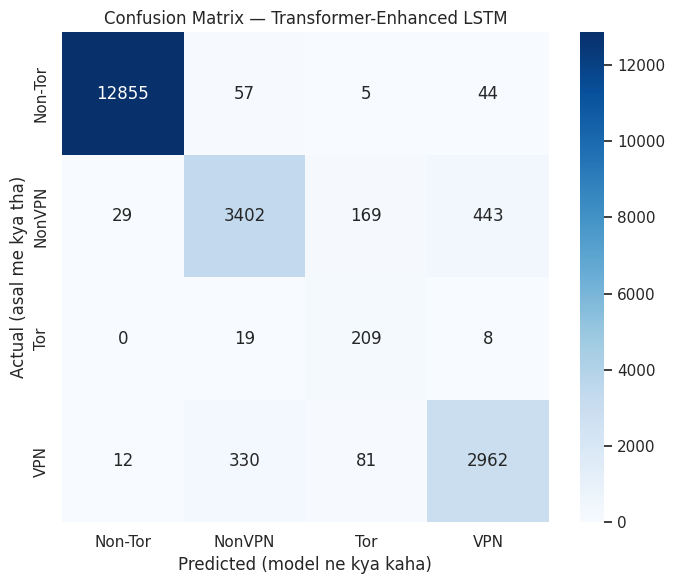

In [16]:
# STEP 16: Confusion Matrix
cm = confusion_matrix(y_test, tl_pred)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Transformer-Enhanced LSTM")
plt.tight_layout()
plt.savefig("figures/confusion_matrix.png", dpi=120)
plt.show()

## 1. Environment Setup

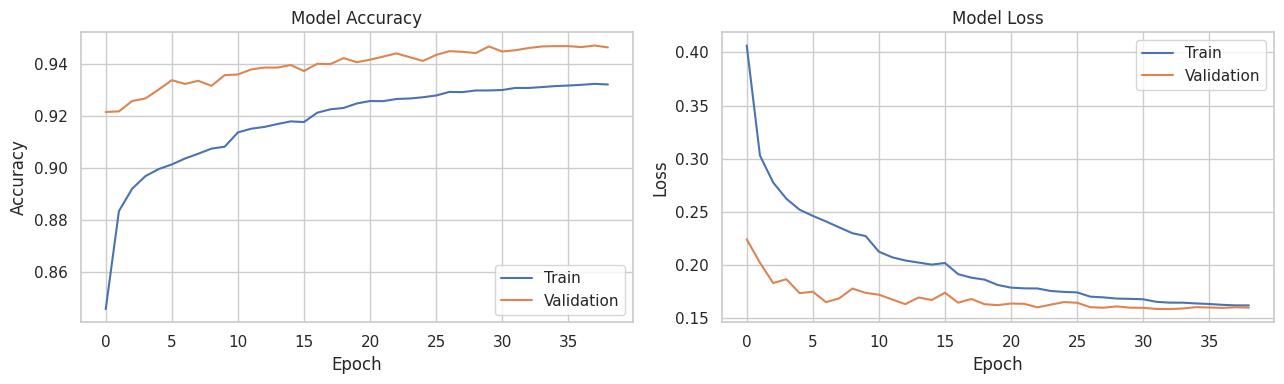

In [17]:
# STEP 17: Accuracy & Loss curves
fig, ax = plt.subplots(1, 2, figsize=(13,4))

ax[0].plot(history.history["accuracy"], label="Train")
ax[0].plot(history.history["val_accuracy"], label="Validation")
ax[0].set_title("Model Accuracy"); ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Accuracy"); ax[0].legend()

ax[1].plot(history.history["loss"], label="Train")
ax[1].plot(history.history["val_loss"], label="Validation")
ax[1].set_title("Model Loss"); ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Loss"); ax[1].legend()

plt.tight_layout()
plt.savefig("figures/accuracy_curve.png", dpi=120)
plt.savefig("figures/loss_curve.png", dpi=120)
plt.show()

## 1. Environment Setup

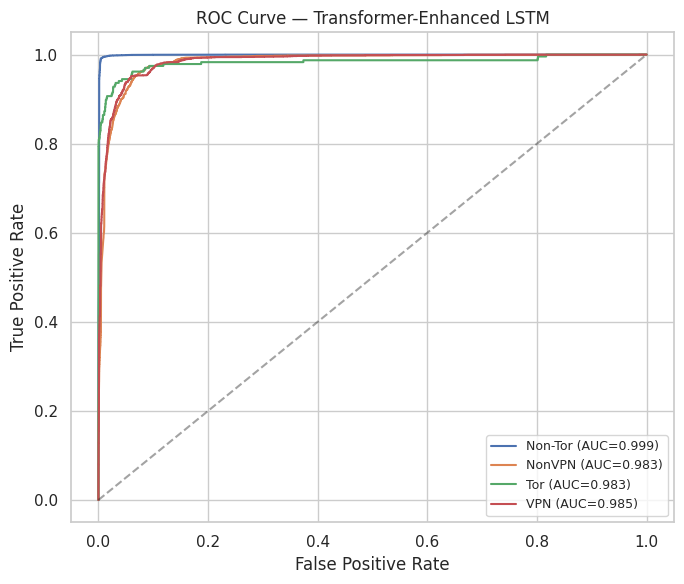

In [18]:
# STEP 18: ROC Curve (one-vs-rest, per class)
from sklearn.metrics import roc_curve, auc as auc_fn

yb = label_binarize(y_test, classes=range(NUM_CLASSES))
plt.figure(figsize=(7,6))
for i, cname in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(yb[:, i], tl_proba[:, i])
    plt.plot(fpr, tpr, label=f"{cname} (AUC={auc_fn(fpr,tpr):.3f})")
plt.plot([0,1], [0,1], "k--", alpha=0.4)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Transformer-Enhanced LSTM")
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig("figures/roc_curve.png", dpi=120)
plt.show()

## 1. Environment Setup

=== FINAL COMPARISON TABLE ===
                    accuracy  precision  recall      f1
XGBoost               0.9808     0.9808  0.9808  0.9807
RandomForest          0.9715     0.9715  0.9715  0.9715
DecisionTree          0.9711     0.9712  0.9711  0.9711
Transformer-LSTM      0.9420     0.9473  0.9420  0.9437
SimpleLSTM            0.9390     0.9455  0.9390  0.9405
KNN                   0.9286     0.9326  0.9286  0.9299
LogisticRegression    0.8251     0.8451  0.8251  0.8310
SVM(Linear)           0.7656     0.7963  0.7656  0.7753


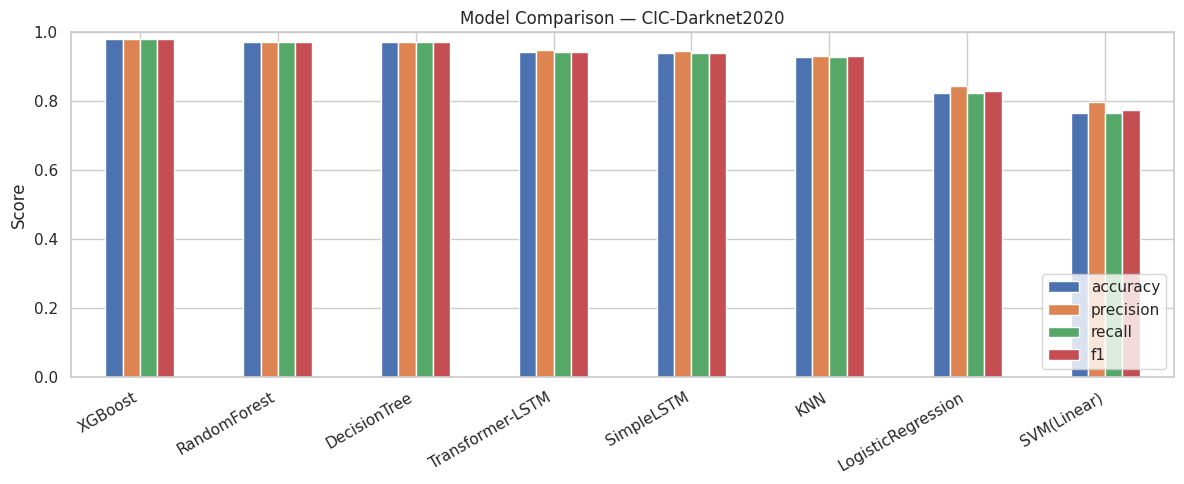


Results saved ✅ (results/metrics.txt + comparison_table.csv)


In [19]:
# STEP 19: Saare models ka comparison + results save
comp = pd.DataFrame(RESULTS).T[["accuracy","precision","recall","f1"]]
comp = comp.sort_values("f1", ascending=False)
print("=== FINAL COMPARISON TABLE ===")
print(comp.round(4))

# Bar chart
comp.plot.bar(figsize=(12,5))
plt.title("Model Comparison — CIC-Darknet2020")
plt.ylabel("Score"); plt.ylim(0,1)
plt.xticks(rotation=30, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("figures/model_comparison.png", dpi=120)
plt.show()

# Save results to file (for the paper)
with open("results/metrics.txt", "w") as f:
    f.write("Model comparison on CIC-Darknet2020 (target=Label)\n\n")
    f.write(comp.to_string())
    f.write("\n\nFull RESULTS:\n")
    f.write(json.dumps(RESULTS, indent=2, default=str))
comp.to_csv("results/comparison_table.csv")
print("\nResults saved (results/metrics.txt + comparison_table.csv)")


## 13. Second Dataset — Protocol Classification

In [20]:
# Upload the second dataset
from google.colab import files
print("Choose the Midterm_53_group.csv file...")
uploaded2 = files.upload()
print("\nUpload complete")
!ls -lh *.csv


Midterm_53_group.csv file choose karo...


Saving Midterm_53_group.csv to Midterm_53_group.csv

Upload done ✅
-rw-r--r-- 1 root root 53M Jun 26 08:28 Midterm_53_group.csv


### Load & Inspect Dataset-2

In [21]:
# STEP 20: Load and inspect the second dataset
df2 = pd.read_csv("Midterm_53_group.csv", low_memory=False)
df2.columns = [c.strip() for c in df2.columns]

print("Shape (rows, columns):", df2.shape)
print("\nColumns:", list(df2.columns))
print("\nPehli 3 rows:")
df2.head(3)

Shape (rows, columns): (394136, 7)

Columns: ['Time', 'Source', 'No.', 'Destination', 'Protocol', 'Length', 'Info']

Pehli 3 rows:


,Time,Source,No.,Destination,Protocol,Length,Info
0,0.000000,192.167.8.166,1,192.167.255.255,NBNS,92,Name query NB WPAD<00>
1,0.784682,192.167.8.166,2,192.167.255.255,NBNS,92,Name query NB WPAD<00>
2,1.169060,VMware_8a:5c:e6,3,Broadcast,ARP,60,Who has 192.167.7.175? Tell 192.167.0.1


In [22]:
# STEP 21: Inspect the Protocol column (classification target)
print("Total unique protocols:", df2["Protocol"].nunique())
print("\nProtocol counts:")
print(df2["Protocol"].value_counts())

Total unique protocols: 16

Protocol counts:
Protocol
TCP        314873
TLSv1.3     71625
ICMP         2690
DNS          1999
TLSv1.2      1763
ARP           447
OCSP          258
NBNS          231
RARP          178
TLSv1          20
DHCP           17
SSLv2          11
ICMPv6          9
BROWSER         8
STUN            4
HTTP            3
Name: count, dtype: int64


### Preprocess Dataset-2

In [23]:
# STEP 22: Preprocess the second dataset
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

d2 = df2.copy()

# Keep only protocols with enough samples (>=200)
keep = d2["Protocol"].value_counts()
keep = keep[keep >= 200].index
d2 = d2[d2["Protocol"].isin(keep)].reset_index(drop=True)
print("Protocols kept:", list(keep))
print("Rows now:", len(d2))

# --- Build features ---
feat = pd.DataFrame()
feat["Length"] = pd.to_numeric(d2["Length"], errors="coerce")
feat["Time"]   = pd.to_numeric(d2["Time"], errors="coerce")
# Length of the Info text (a simple feature)
feat["info_len"] = d2["Info"].astype(str).str.len()
# Encode Source/Destination as integers
feat["src_enc"] = LabelEncoder().fit_transform(d2["Source"].astype(str))
feat["dst_enc"] = LabelEncoder().fit_transform(d2["Destination"].astype(str))
# Broadcast/multicast flag
feat["is_broadcast"] = d2["Destination"].astype(str).str.contains("255|Broadcast", case=False).astype(int)

feat = feat.fillna(0)

# Target = Protocol
le2 = LabelEncoder()
y2 = le2.fit_transform(d2["Protocol"].astype(str))
CLASS_NAMES_2 = list(le2.classes_)
NUM_CLASSES_2 = len(CLASS_NAMES_2)

print("\nFeatures shape:", feat.shape)
print("Classes:", dict(enumerate(CLASS_NAMES_2)))

Rakhe gaye protocols: ['TCP', 'TLSv1.3', 'ICMP', 'DNS', 'TLSv1.2', 'ARP', 'OCSP', 'NBNS']
Rows ab: 393886

Features shape: (393886, 6)
Classes: {0: 'ARP', 1: 'DNS', 2: 'ICMP', 3: 'NBNS', 4: 'OCSP', 5: 'TCP', 6: 'TLSv1.2', 7: 'TLSv1.3'}


### Train Transformer-LSTM on Dataset-2

In [24]:
# STEP 23: Train the Transformer-LSTM on the second dataset
from imblearn.over_sampling import SMOTE

# Split
X2_train, X2_test, y2_train, y2_test = train_test_split(
    feat.values, y2, test_size=0.20, stratify=y2, random_state=SEED)

# Scale
scaler2 = StandardScaler()
X2_train = scaler2.fit_transform(X2_train)
X2_test  = scaler2.transform(X2_test)

# SMOTE (training set only)
print("Before SMOTE:", Counter(y2_train))
X2_train, y2_train = SMOTE(random_state=SEED, k_neighbors=3).fit_resample(X2_train, y2_train)
print("After SMOTE: ", Counter(y2_train))

N_FEAT2 = X2_train.shape[1]

# Reshape for the LSTM
X2tr = X2_train.reshape((-1, 1, N_FEAT2))
X2te = X2_test.reshape((-1, 1, N_FEAT2))

# Same Transformer-LSTM architecture, applied to the new dataset
model2 = build_transformer_lstm(N_FEAT2, NUM_CLASSES_2)
model2.compile(optimizer=optimizers.Adam(1e-3),
               loss="sparse_categorical_crossentropy", metrics=["accuracy"])

hist2 = model2.fit(X2tr, y2_train, validation_split=0.1,
                   epochs=20, batch_size=512,
                   callbacks=[callbacks.EarlyStopping(monitor="val_loss", patience=4,
                                                      restore_best_weights=True)],
                   verbose=2)
print("\nDataset-2 training complete")

SMOTE se pehle: Counter({np.int64(5): 251898, np.int64(7): 57300, np.int64(2): 2152, np.int64(1): 1599, np.int64(6): 1410, np.int64(0): 358, np.int64(4): 206, np.int64(3): 185})
SMOTE ke baad:  Counter({np.int64(5): 251898, np.int64(7): 251898, np.int64(1): 251898, np.int64(2): 251898, np.int64(0): 251898, np.int64(6): 251898, np.int64(3): 251898, np.int64(4): 251898})
Epoch 1/20
3543/3543 - 75s - 21ms/step - accuracy: 0.9769 - loss: 0.0696 - val_accuracy: 0.8728 - val_loss: 0.4030
Epoch 2/20
3543/3543 - 69s - 19ms/step - accuracy: 0.9901 - loss: 0.0337 - val_accuracy: 0.8806 - val_loss: 0.3956
Epoch 3/20
3543/3543 - 81s - 23ms/step - accuracy: 0.9922 - loss: 0.0283 - val_accuracy: 0.8770 - val_loss: 0.3628
Epoch 4/20
3543/3543 - 68s - 19ms/step - accuracy: 0.9917 - loss: 0.0300 - val_accuracy: 0.8963 - val_loss: 0.3380
Epoch 5/20
3543/3543 - 83s - 23ms/step - accuracy: 0.9940 - loss: 0.0227 - val_accuracy: 0.8190 - val_loss: 0.5393
Epoch 6/20
3543/3543 - 69s - 20ms/step - accuracy: 0.

### Evaluate Dataset-2

In [25]:
# STEP 24: Final evaluation on Dataset-2
p2 = model2.predict(X2te, verbose=0)
pred2 = p2.argmax(1)

acc2 = accuracy_score(y2_test, pred2)
f1_2 = f1_score(y2_test, pred2, average="weighted", zero_division=0)
prec2 = precision_score(y2_test, pred2, average="weighted", zero_division=0)
rec2 = recall_score(y2_test, pred2, average="weighted", zero_division=0)

print("=== Dataset-2 (Protocol Classification) — Transformer-LSTM ===")
print(f"Accuracy : {acc2:.4f}")
print(f"Precision: {prec2:.4f}")
print(f"Recall   : {rec2:.4f}")
print(f"F1 Score : {f1_2:.4f}")

print("\n=== Per-class report ===\n")
print(classification_report(y2_test, pred2, target_names=CLASS_NAMES_2, zero_division=0))

=== Dataset-2 (Protocol Classification) — Transformer-LSTM ===
Accuracy : 0.9900
Precision: 0.9961
Recall   : 0.9900
F1 Score : 0.9922

=== Per-class report ===

              precision    recall  f1-score   support

         ARP       1.00      1.00      1.00        89
         DNS       0.99      1.00      0.99       400
        ICMP       0.96      1.00      0.98       538
        NBNS       1.00      1.00      1.00        46
        OCSP       1.00      1.00      1.00        52
         TCP       1.00      1.00      1.00     62975
     TLSv1.2       0.32      0.95      0.47       353
     TLSv1.3       1.00      0.95      0.97     14325

    accuracy                           0.99     78778
   macro avg       0.91      0.99      0.93     78778
weighted avg       1.00      0.99      0.99     78778



## 14. Cross-Dataset Comparison

=== CROSS-DATASET COMPARISON (Transformer-Enhanced LSTM) ===

                       Dataset  Accuracy     F1  Classes
CIC-Darknet2020 (Traffic Type)     0.942 0.9437        4
    Midterm_53 (Protocol Type)     0.990 0.9922        8


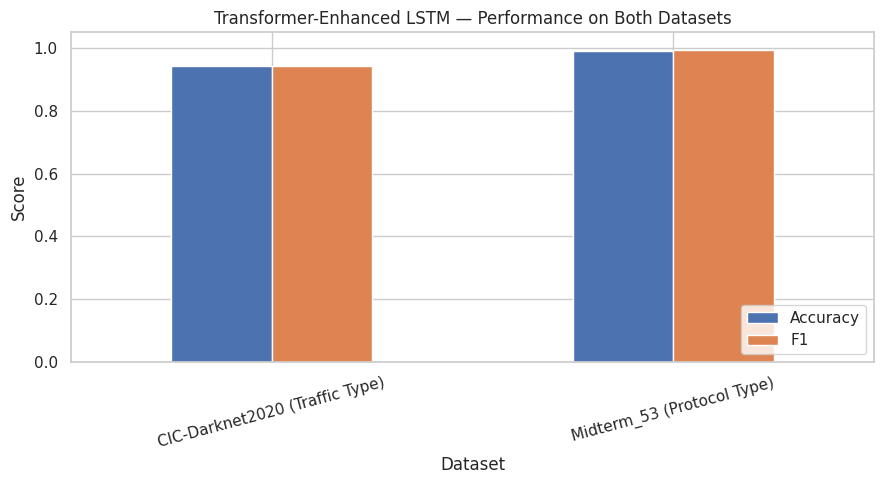


✅ CODE COMPLETE! Dono datasets done. Results saved.


In [26]:
# STEP 25: Cross-dataset comparison + save
cross = pd.DataFrame([
    {"Dataset":"CIC-Darknet2020 (Traffic Type)",
     "Accuracy":RESULTS["Transformer-LSTM"]["accuracy"],
     "F1":RESULTS["Transformer-LSTM"]["f1"],
     "Classes":NUM_CLASSES},
    {"Dataset":"Midterm_53 (Protocol Type)",
     "Accuracy":acc2, "F1":f1_2, "Classes":NUM_CLASSES_2},
])
print("=== CROSS-DATASET COMPARISON (Transformer-Enhanced LSTM) ===\n")
print(cross.round(4).to_string(index=False))

# Bar chart
cross.set_index("Dataset")[["Accuracy","F1"]].plot.bar(figsize=(9,5), rot=15)
plt.title("Transformer-Enhanced LSTM — Performance on Both Datasets")
plt.ylabel("Score"); plt.ylim(0,1.05)
plt.legend(loc="lower right"); plt.tight_layout()
plt.savefig("figures/cross_dataset.png", dpi=120)
plt.show()

# Save
cross.to_csv("results/cross_dataset.csv", index=False)
print("\nCODE COMPLETE. Both datasets processed. Results saved.")